In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load the dataset
df = pd.read_csv("house_price_dataset.csv")

df.head()

,area_sqft,bedrooms,bathrooms,stories,parking_spaces,house_age,distance_city_km,property_type,location_quality,furnishing_status,mainroad,basement,has_garden,price
0,989,1,3.0,3,2.0,24,27.6,House,High,Unfurnished,Yes,No,No,10703248
1,5132,4,4.0,3,1.0,1,8.8,Apartment,Medium,Unfurnished,Yes,No,No,43348706
2,4410,4,1.0,3,1.0,37,16.0,Apartment,Medium,Semi-Furnished,Yes,Yes,No,37088859
3,3105,2,4.0,2,0.0,25,6.7,Townhouse,Low,Unfurnished,No,Yes,Yes,29425328
4,3069,1,5.0,1,0.0,42,22.6,House,Low,Semi-Furnished,No,Yes,No,22336916


In [3]:
# print the shape of the dataset, column names, and data types
print("Shape of the dataset:", df.shape)
print("Column names:", df.columns)
print("Data types:", df.dtypes)

Shape of the dataset: (1847, 14)
Column names: Index(['area_sqft', 'bedrooms', 'bathrooms', 'stories', 'parking_spaces',
       'house_age', 'distance_city_km', 'property_type', 'location_quality',
       'furnishing_status', 'mainroad', 'basement', 'has_garden', 'price'],
      dtype='str')
Data types: area_sqft              int64
bedrooms               int64
bathrooms            float64
stories                int64
parking_spaces       float64
house_age              int64
distance_city_km     float64
property_type            str
location_quality         str
furnishing_status        str
mainroad                 str
basement                 str
has_garden               str
price                  int64
dtype: object


In [4]:
# Missing values check
missing_values = pd.DataFrame({
    "missing_count": df.isnull().sum(),
    "missing_percentage": (df.isnull().mean() * 100).round(2)
}).sort_values(by="missing_count", ascending=False)

missing_values

,missing_count,missing_percentage
distance_city_km,77,4.17
furnishing_status,75,4.06
parking_spaces,73,3.95
location_quality,73,3.95
bathrooms,72,3.90
bedrooms,0,0.00
house_age,0,0.00
stories,0,0.00
area_sqft,0,0.00
property_type,0,0.00


In [5]:
total_missing = df.isnull().sum().sum()

print(f"Total missing values in dataset: {total_missing}")

if total_missing == 0:
    print("No missing values found. The dataset is complete and ready for further analysis.")
else:
    print("Missing values found in the following columns:")
    display(missing_values[missing_values["missing_count"] > 0])

Total missing values in dataset: 370
Missing values found in the following columns:


,missing_count,missing_percentage
distance_city_km,77,4.17
furnishing_status,75,4.06
parking_spaces,73,3.95
location_quality,73,3.95
bathrooms,72,3.90


### Missing Values Check

We checked the dataset for missing values across all columns. This step ensures that the data is complete before moving into deeper exploratory data analysis and model building.

If missing values are present, they will need to be handled using suitable techniques such as imputation or row removal depending on the column type and missing percentage.

In [6]:
# check for duplicates
duplicates = df.duplicated().sum()

print(f"Number of duplicate rows in the dataset: {duplicates}")

Number of duplicate rows in the dataset: 45


In [7]:
# drop duplicates if any
if duplicates > 0:
    df = df.drop_duplicates()
    print(f"Duplicate rows dropped. New shape of the dataset: {df.shape}")
else:
    print("No duplicate rows found. The dataset is clean and ready for analysis.")
    

Duplicate rows dropped. New shape of the dataset: (1802, 14)


In [8]:
df.describe()

,area_sqft,bedrooms,bathrooms,stories,parking_spaces,house_age,distance_city_km,price
count,1802.000000,1802.000000,1730.000000,1802.000000,1730.000000,1802.000000,1730.000000,1.802000e+03
mean,3515.896226,3.994451,2.976879,1.957825,1.490173,27.140400,20.560694,3.078994e+07
std,2065.407828,2.067429,1.442773,0.835363,1.136780,16.284933,12.700174,1.446532e+07
min,120.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2.000000e+05
25%,1970.000000,2.000000,2.000000,1.000000,0.000000,14.000000,10.700000,1.890947e+07
50%,3502.500000,4.000000,3.000000,2.000000,1.000000,26.000000,20.700000,3.084049e+07
75%,5024.250000,6.000000,4.000000,3.000000,2.000000,40.000000,29.900000,4.218859e+07
max,50000.000000,25.000000,15.000000,8.000000,12.000000,180.000000,250.000000,2.500000e+08


### Statistical Summary

The statistical summary provides an overview of the numerical features in the dataset, including central tendency, spread, and possible outliers.

Some columns have lower count values, which indicates missing data. In particular, bathrooms, parking spaces, and distance from city contain missing values.

The summary also suggests the presence of potential outliers, such as very large property sizes, unusually high bedroom and bathroom counts, old house ages, and very high property prices. These values should be investigated during exploratory data analysis.

In [9]:
# Check missing values again after summary
df.isnull().sum()

area_sqft             0
bedrooms              0
bathrooms            72
stories               0
parking_spaces       72
house_age             0
distance_city_km     72
property_type         0
location_quality     72
furnishing_status    72
mainroad              0
basement              0
has_garden            0
price                 0
dtype: int64

### Missing Values Handling Strategy

Missing values were identified in the dataset. Instead of filling them directly in the dataframe, missing values will be handled later using a machine learning preprocessing pipeline.

For numerical columns, median imputation will be used because it is robust against outliers. For categorical columns, the most frequent value will be used if missing values are present.

This pipeline-based approach prevents data leakage and ensures that the same preprocessing steps are applied consistently during model training and future predictions.

In [10]:
# Missing values summary
missing_values = pd.DataFrame({
    "missing_count": df.isnull().sum(),
    "missing_percentage": (df.isnull().mean() * 100).round(2)
}).sort_values(by="missing_count", ascending=False)

missing_values[missing_values["missing_count"] > 0]

,missing_count,missing_percentage
parking_spaces,72,4.0
bathrooms,72,4.0
location_quality,72,4.0
furnishing_status,72,4.0
distance_city_km,72,4.0


In [14]:
# Separate numerical and categorical columns
from train_house_model import TARGET


numerical_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()

print("Numerical Columns:")
print(numerical_cols)

print("\nCategorical Columns:")
print(categorical_cols)

# Separate target from numerical feature columns
target_col = "price"

numerical_features = [col for col in numerical_cols if col != target_col]

print("Numerical Features:")
print(numerical_features)

print("\nCategorical Features:")
print(categorical_cols)

print("\nTarget Column:")
print(target_col)



Numerical Columns:
['area_sqft', 'bedrooms', 'bathrooms', 'stories', 'parking_spaces', 'house_age', 'distance_city_km', 'price']

Categorical Columns:
['property_type', 'location_quality', 'furnishing_status', 'mainroad', 'basement', 'has_garden']
Numerical Features:
['area_sqft', 'bedrooms', 'bathrooms', 'stories', 'parking_spaces', 'house_age', 'distance_city_km']

Categorical Features:
['property_type', 'location_quality', 'furnishing_status', 'mainroad', 'basement', 'has_garden']

Target Column:
price


C:\Users\HP\AppData\Local\Temp\ipykernel_8132\626267644.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()


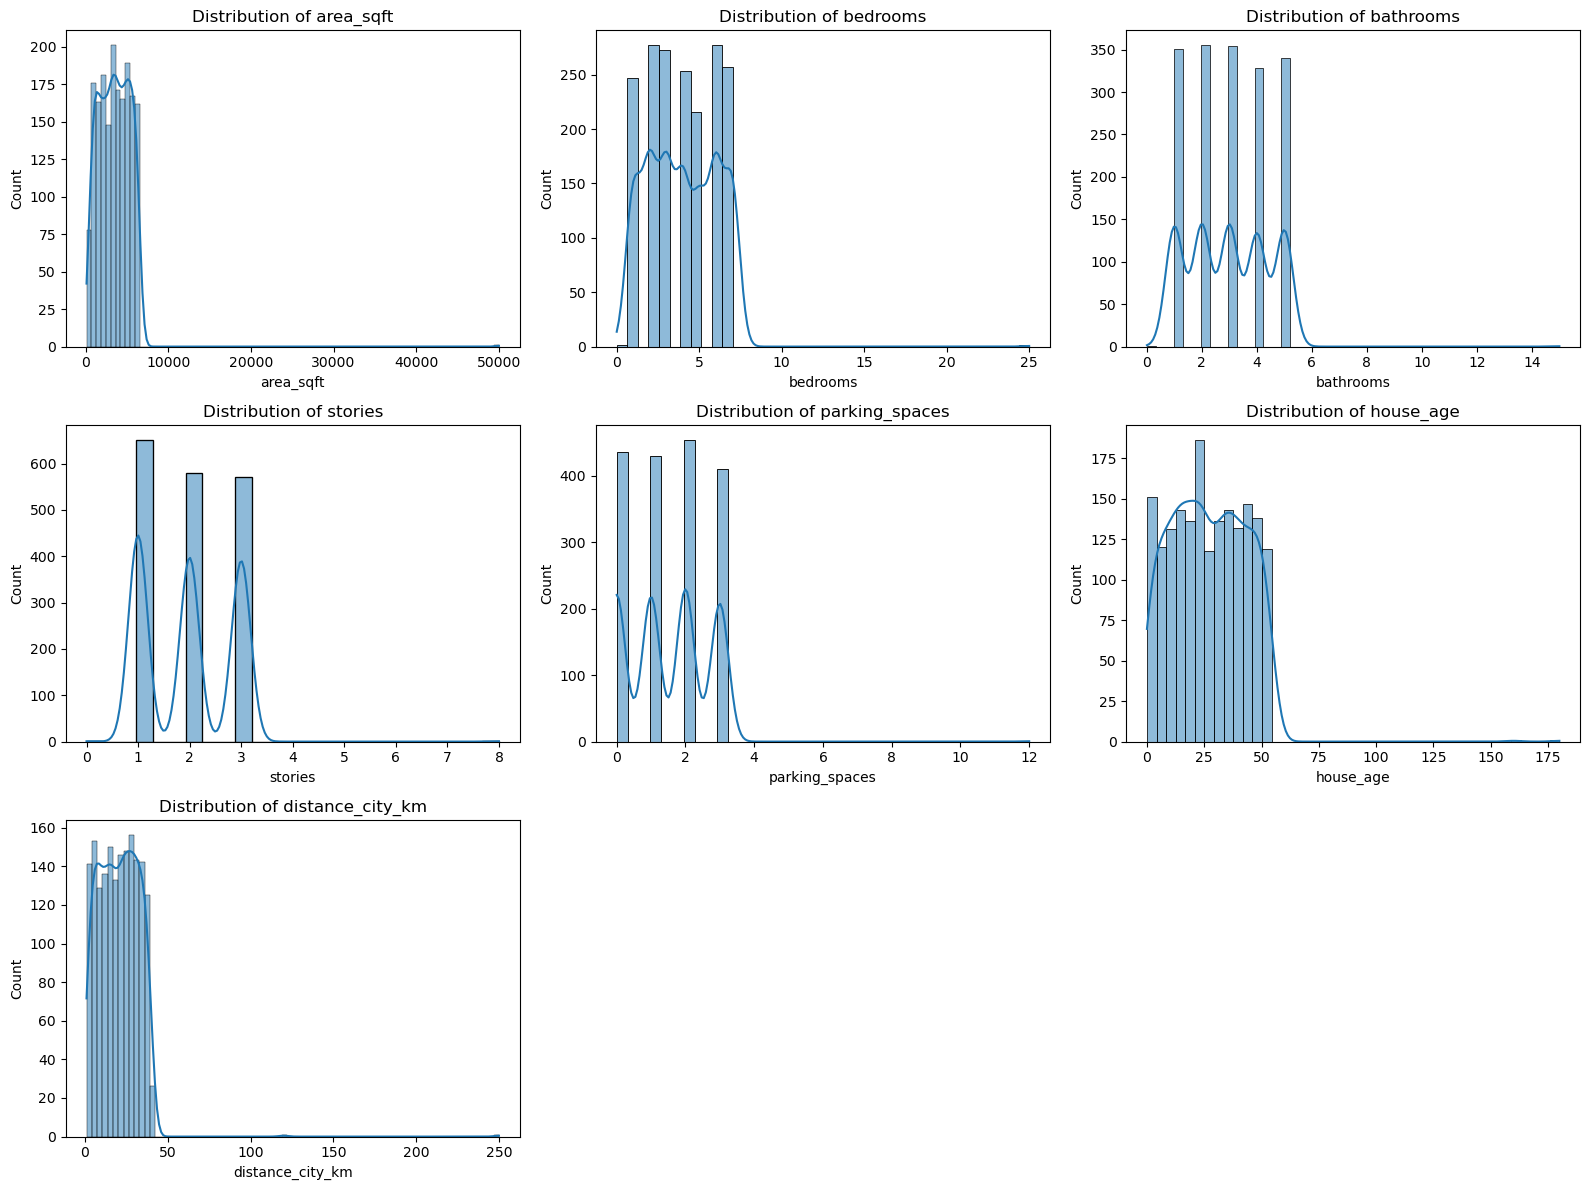

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# Numerical feature distributions
plt.figure(figsize=(16, 12))

for i, col in enumerate(numerical_features, 1):
    plt.subplot(3, 3, i)
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")

plt.tight_layout()
plt.show()

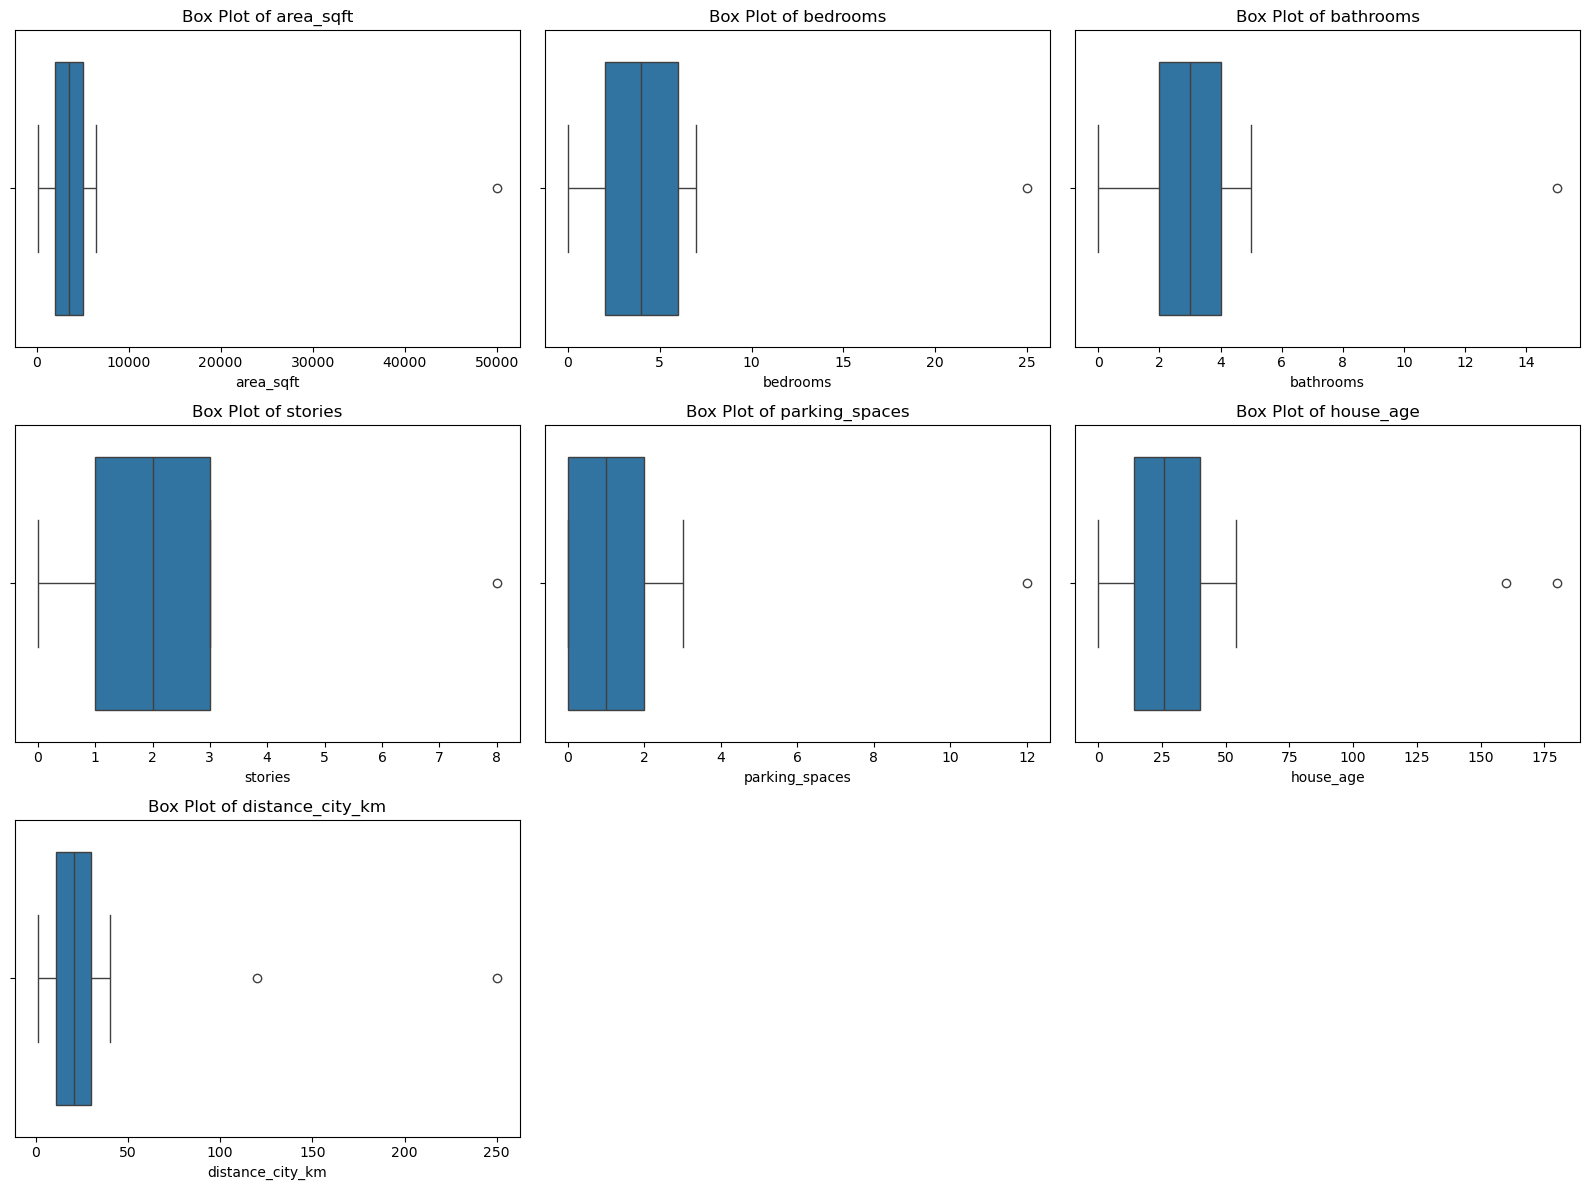

In [17]:
# box plots for numerical features
plt.figure(figsize=(16, 12))

for i, col in enumerate(numerical_features, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(x=df[col])
    plt.title(f"Box Plot of {col}")

plt.tight_layout()
plt.show()



### Numerical Feature Distributions

The distribution plots show that several numerical features are right-skewed. This skewness appears to be influenced by extreme values in columns such as area, bedrooms, bathrooms, house age, parking spaces, and distance from the city.

To investigate these extreme values further, boxplots are used to visually identify potential outliers in the numerical features.

### Outlier Analysis

Boxplots confirm the presence of outliers in several numerical features. Extreme values are visible in area, bedrooms, bathrooms, stories, parking spaces, house age, and distance from the city.

These outliers may represent luxury properties, unusual listings, or intentionally generated extreme records. Since removing them without investigation may lead to information loss, they will be retained at this stage and considered later during preprocessing and model evaluation.

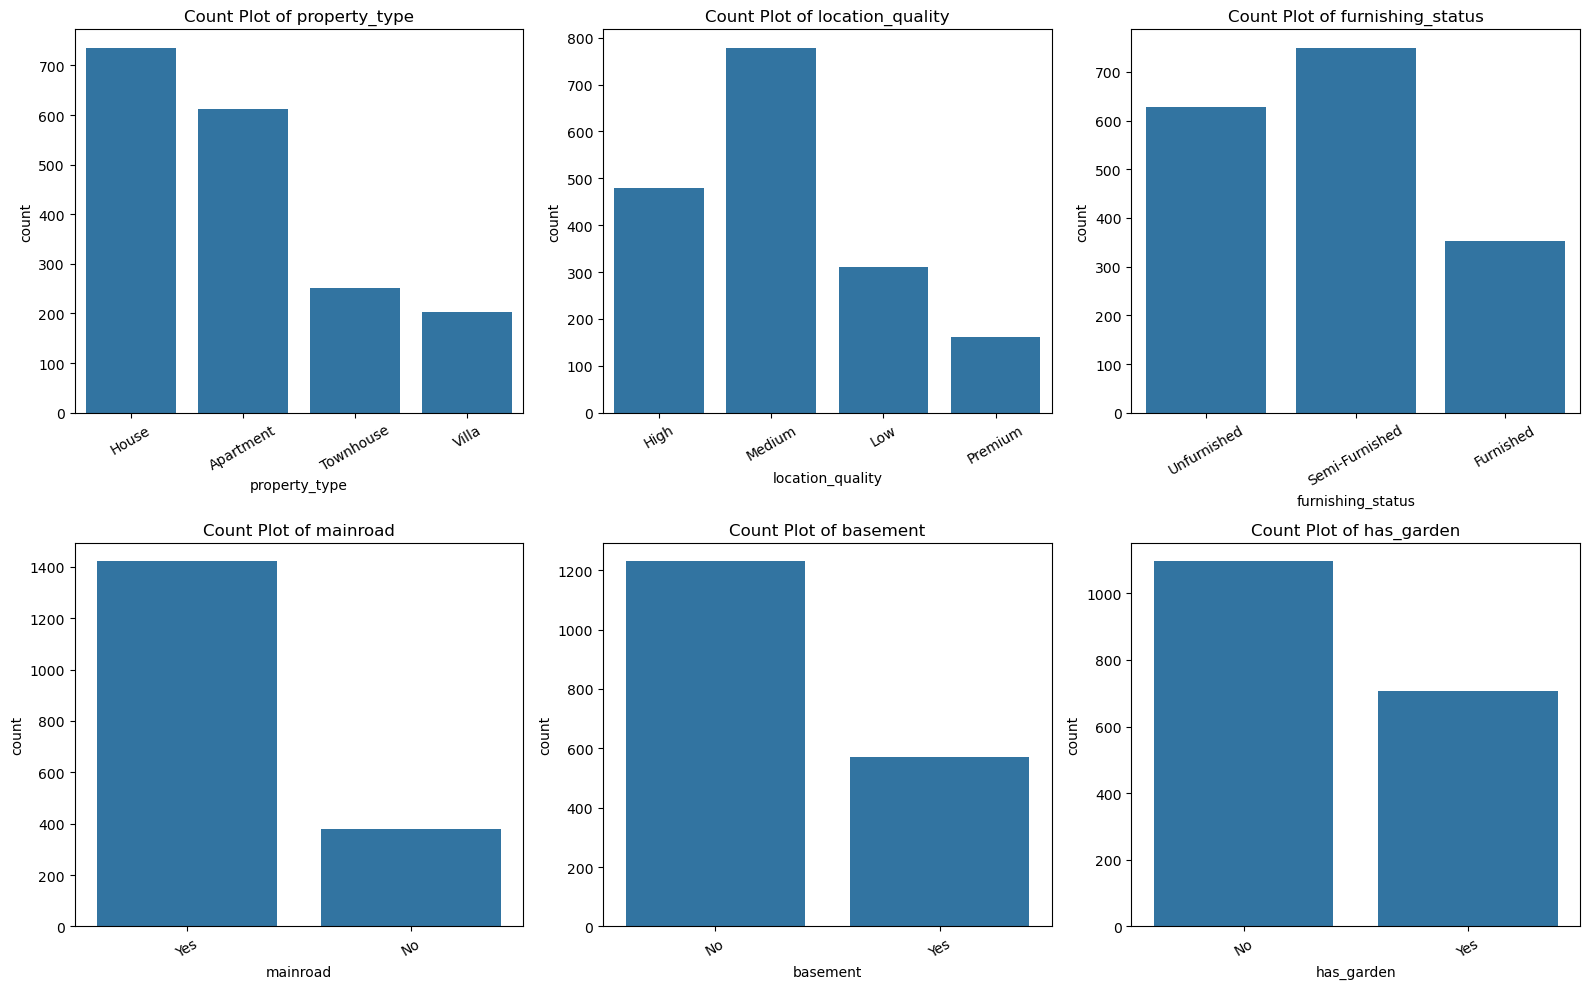

In [18]:
# Count plots for categorical features
plt.figure(figsize=(16, 10))

for i, col in enumerate(categorical_cols, 1):
    plt.subplot(2, 3, i)
    sns.countplot(data=df, x=col)
    plt.title(f"Count Plot of {col}")
    plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

### Categorical Feature Distribution

The categorical feature count plots show that all categories appear valid and interpretable.

Houses are the most common property type, while villas are the least common. Most properties have medium location quality, and premium locations are relatively less frequent. Semi-furnished properties are the most common furnishing category.

For binary features, most properties are located on the main road, while basements and gardens are less common. These category distributions will be useful later when analyzing their relationship with house price.

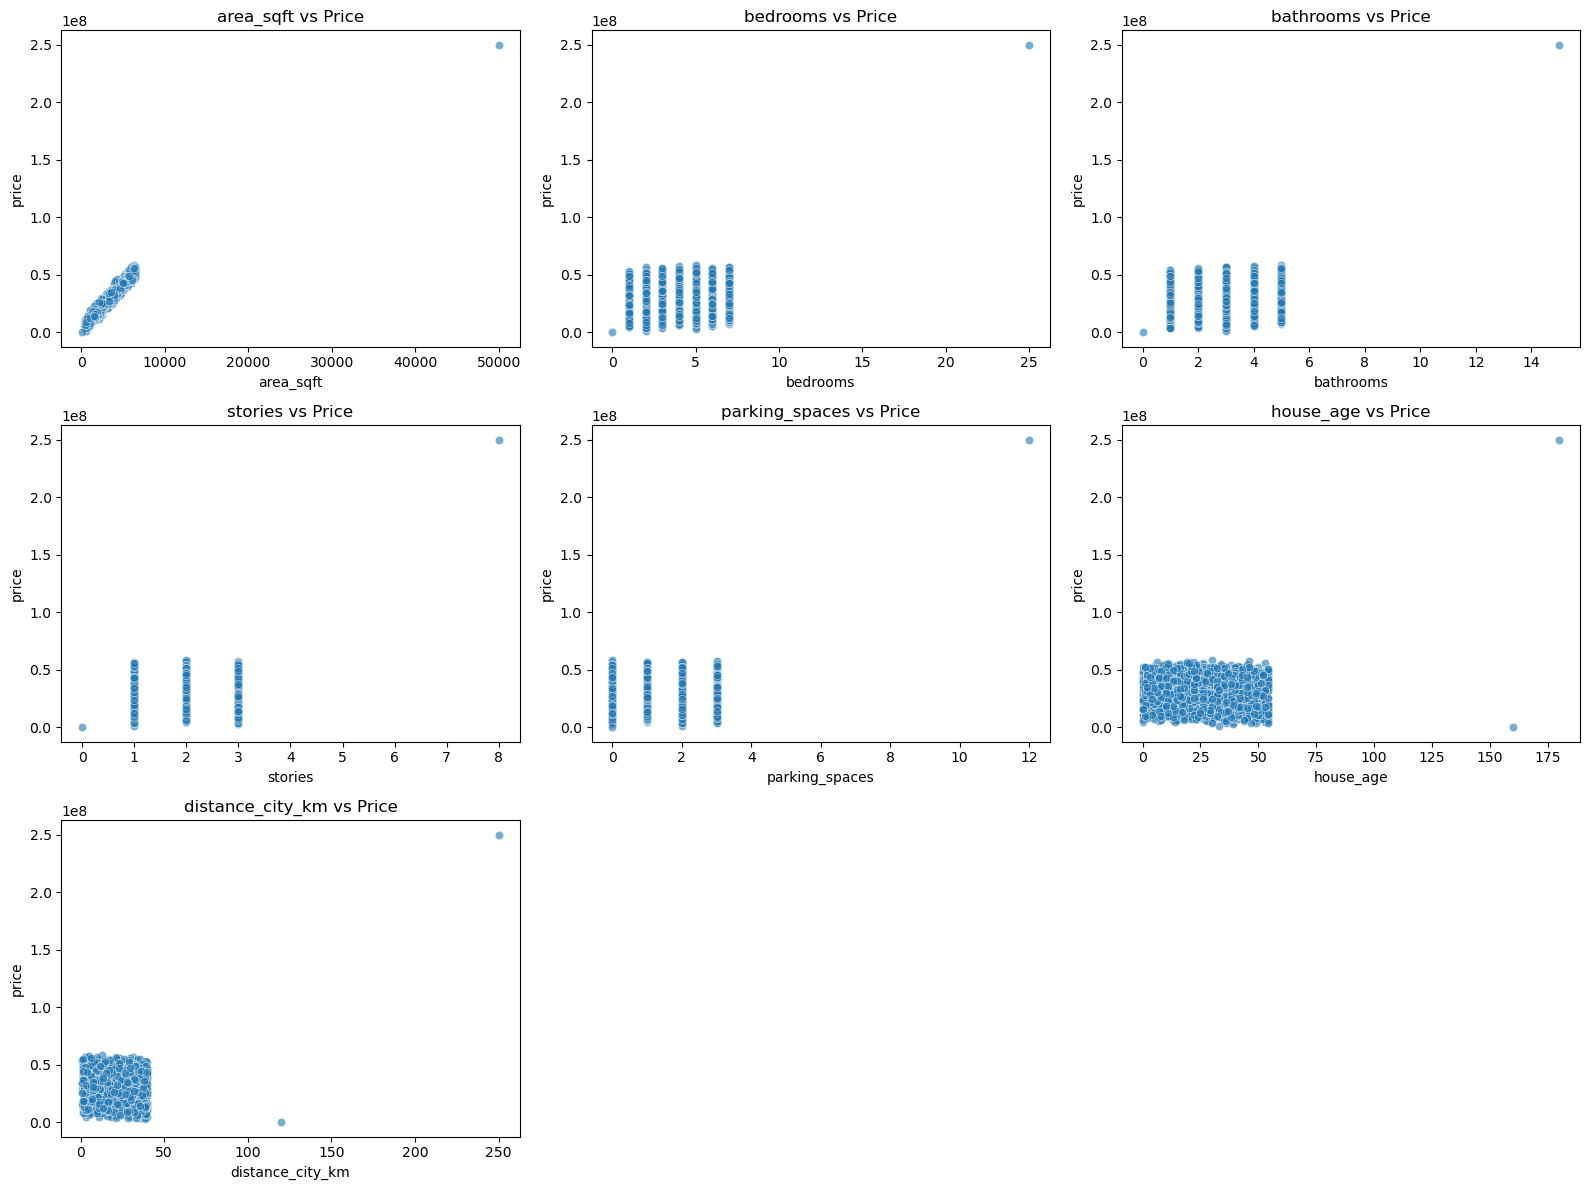

In [20]:


# Relationship between numerical features and price
plt.figure(figsize=(16, 12))

for i, col in enumerate(numerical_features, 1):
    plt.subplot(3, 3, i)
    sns.scatterplot(data=df, x=col, y="price", alpha=0.6)
    plt.title(f"{col} vs Price")

plt.tight_layout()
plt.show()

### Numerical Features vs Price

Scatter plots are used to analyze the relationship between numerical features and the target variable, price. These plots help identify trends, linear or non-linear relationships, and the impact of outliers on property prices.

In [21]:
# Create temporary dataframe for cleaner visualization without extreme outliers
df_viz = df[
    (df["area_sqft"] < df["area_sqft"].quantile(0.99)) &
    (df["price"] < df["price"].quantile(0.99)) &
    (df["house_age"] < df["house_age"].quantile(0.99)) &
    (df["distance_city_km"] < df["distance_city_km"].quantile(0.99))
]

print("Original shape:", df.shape)
print("Visualization shape:", df_viz.shape)

Original shape: (1802, 14)
Visualization shape: (1640, 14)


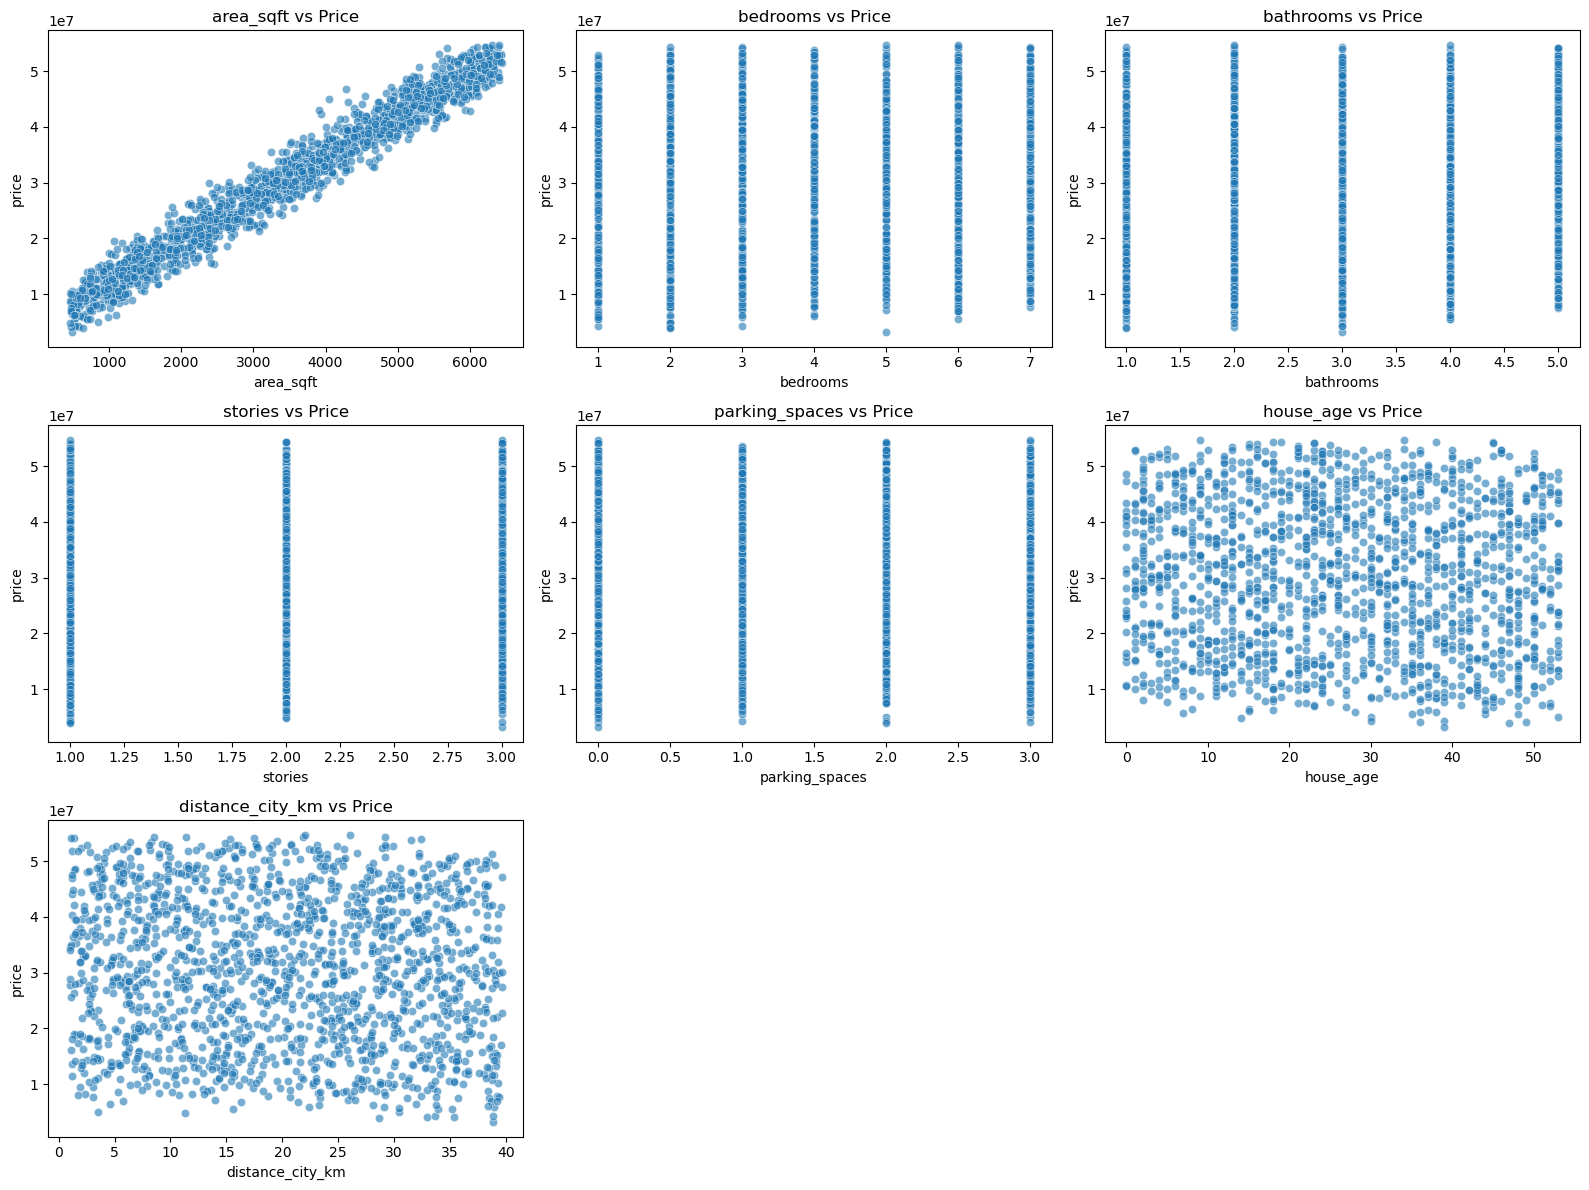

In [22]:
# Numerical features vs price after excluding extreme outliers for visualization
plt.figure(figsize=(16, 12))

for i, col in enumerate(numerical_features, 1):
    plt.subplot(3, 3, i)
    sns.scatterplot(data=df_viz, x=col, y="price", alpha=0.6)
    plt.title(f"{col} vs Price")

plt.tight_layout()
plt.show()

### Interpretation of Numerical Features vs Price

The scatter plots show how each numerical feature is related to the target variable, price.

**Area vs Price:**  
Area has the clearest positive relationship with price. As `area_sqft` increases, the price also increases. This suggests that property area is one of the strongest predictors of house price.

**Bedrooms vs Price:**  
Bedrooms show vertical clusters because bedroom count is a discrete variable. Prices vary within each bedroom count, and there is no very strong linear pattern. This means bedrooms alone may not explain price well, but it can still be useful with other features.

**Bathrooms vs Price:**  
Bathrooms also show vertical clusters. Prices are spread across each bathroom count, so the relationship is not very strong individually. However, bathrooms may still contribute to price prediction when combined with area and other property features.

**Stories vs Price:**  
Stories are grouped into a few fixed values. The plot does not show a clear increasing or decreasing trend. This suggests that the number of stories alone may have limited impact on price.

**Parking Spaces vs Price:**  
Parking spaces also show discrete clusters. There is no strong direct relationship visible, although properties with more parking may still be associated with better or larger houses.

**House Age vs Price:**  
House age does not show a clear trend with price. Prices are spread across both newer and older houses, suggesting that age alone is not a strong predictor in this dataset.

**Distance from City vs Price:**  
Distance from the city does not show a strong visible relationship with price in this plot. Prices are widely spread at different distances, so this feature may need further analysis or may interact with location quality.

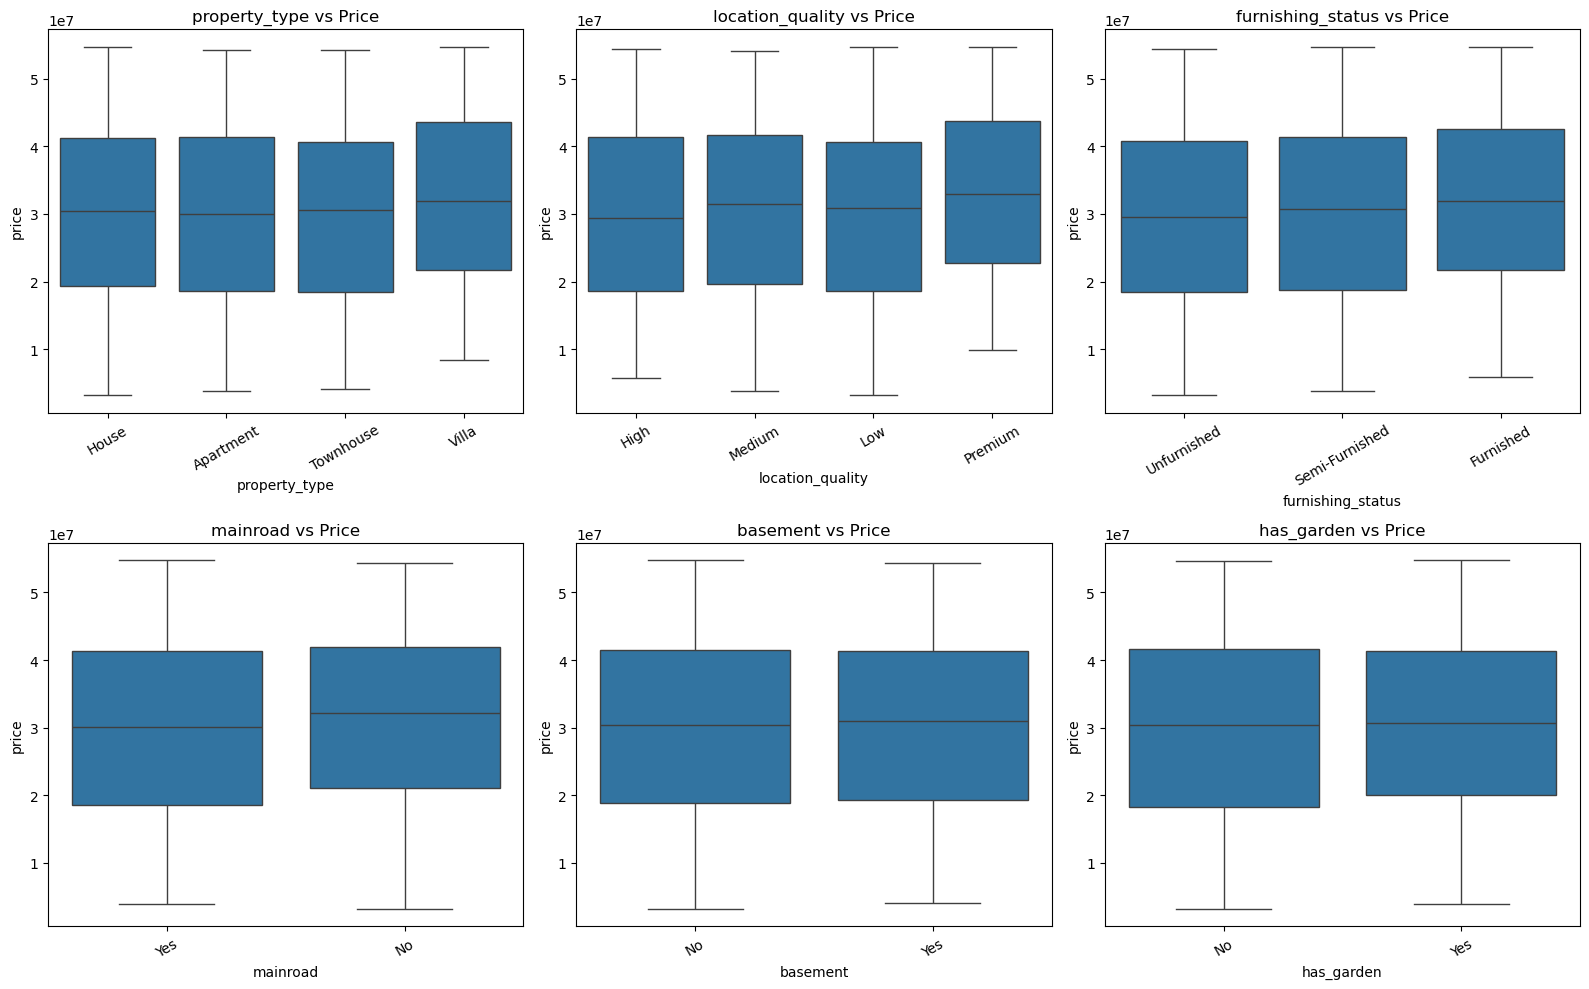

In [25]:
# Relationship between categorical features and price
plt.figure(figsize=(16, 10))

for i, col in enumerate(categorical_cols, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(data=df_viz, x=col, y="price")
    plt.title(f"{col} vs Price")
    plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

### Interpretation of Categorical Features vs Price

The boxplots show how house prices vary across different categorical feature groups.

**Property Type vs Price:**  
Villa properties have a slightly higher median price compared to houses, apartments, and townhouses. This suggests that villas may generally be more expensive. Other property types have fairly similar price distributions.

**Location Quality vs Price:**  
Premium locations show the highest median price, followed by medium and low categories. This indicates that location quality has a visible effect on house price. Properties in premium locations tend to be priced higher.

**Furnishing Status vs Price:**  
Furnished properties have a slightly higher median price than semi-furnished and unfurnished properties. This suggests that better furnishing may add value to a property, although the difference is not extremely large.

**Mainroad vs Price:**  
Properties not on the main road show a slightly higher median price in this dataset. The difference is small, so main road access may not be a very strong individual predictor here.

**Basement vs Price:**  
Properties with a basement have a slightly higher median price than properties without a basement. This suggests that basement availability may add some value, but the impact appears moderate.

**Garden vs Price:**  
Properties with a garden have a slightly higher median price compared to properties without a garden. This indicates that garden availability may have a positive effect on price, though the difference is not very large.

Overall, categorical features such as location quality, property type, furnishing status, basement, and garden show some differences in price distribution. However, most category differences are moderate, so these features are likely more useful when combined with numerical features in the machine learning model.

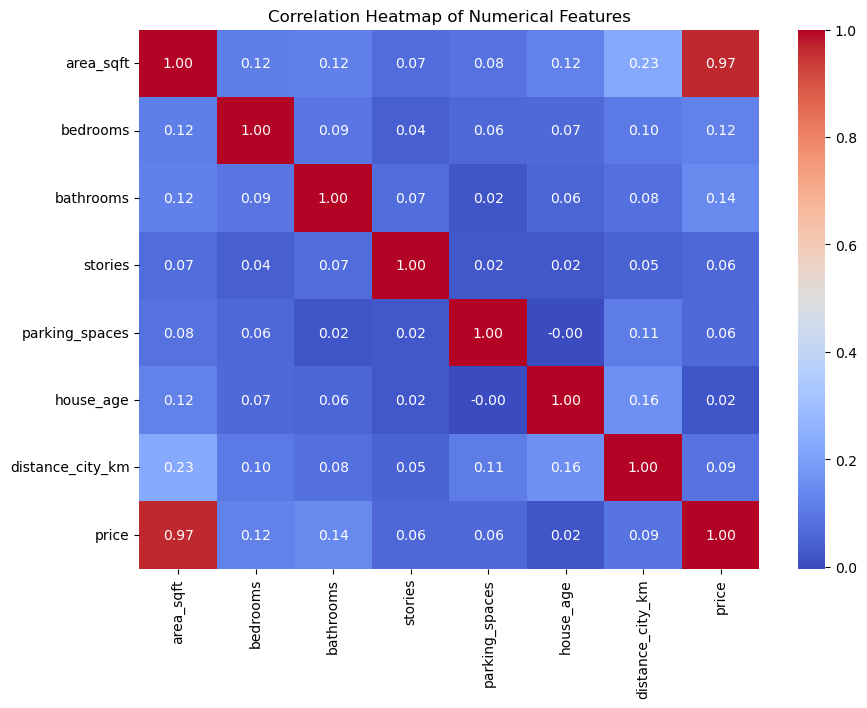

In [26]:
# Correlation heatmap for numerical columns
plt.figure(figsize=(10, 7))

correlation_matrix = df[numerical_cols].corr()

sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Numerical Features")

plt.show()

In [27]:
# seprate target from features
X = df.drop(columns=[target_col])
y = df[target_col]

# Split the data into training and testing sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)    

X_train shape: (1441, 13)
X_test shape: (361, 13)
y_train shape: (1441,)
y_test shape: (361,)


In [28]:
# pipelines for numerical and categorical features
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))      
])

from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer([
    ("num", num_pipeline, numerical_features),
    ("cat", cat_pipeline, categorical_cols) 
])
preprocessor

,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'median'
,fill_value,None


In [33]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Create Linear Regression pipeline
linear_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])
linear_model 

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [34]:
# train the model
linear_model.fit(X_train, y_train)
# Make predictions
y_pred_linear = linear_model.predict(X_test)

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred_linear)
mse = mean_squared_error(y_test, y_pred_linear)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_linear)

print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("R-squared (R2) Score:", r2)

Mean Absolute Error (MAE): 1210748.9647904467
Mean Squared Error (MSE): 48814960871334.734
Root Mean Squared Error (RMSE): 6986770.417820721
R-squared (R2) Score: 0.8473210154228278


### Linear Regression Model Evaluation

The Linear Regression model achieved an R² score of 0.8473, which means the model explains approximately 84.7% of the variation in house prices.

The Mean Absolute Error is around 1.21 million, meaning that on average, the model's predictions differ from the actual prices by about 1.21 million.

The RMSE is higher than MAE, which suggests that some predictions have large errors. This is likely influenced by extreme outliers in the dataset.

Overall, Linear Regression provides a strong baseline model, but performance may be improved using more flexible models such as Decision Tree, Random Forest, or Gradient Boosting.

In [36]:
# descion tree regressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Create Decision Tree Regressor pipeline
decision_tree_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", DecisionTreeRegressor(random_state=42))
])
decision_tree_model

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [38]:
# fit and transform the training data, then transform the test data
X_train_preprocessed = preprocessor.fit_transform(X_train)
X_test_preprocessed = preprocessor.transform(X_test)

from sklearn.tree import DecisionTreeRegressor

# Create Decision Tree pipeline
decision_tree_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", DecisionTreeRegressor(random_state=42))
])

# Train on raw training data
decision_tree_model.fit(X_train, y_train)

# Predict on raw test data
y_pred_decision_tree = decision_tree_model.predict(X_test)

In [39]:
mae_tree = mean_absolute_error(y_test, y_pred_decision_tree)
mse_tree = mean_squared_error(y_test, y_pred_decision_tree)
rmse_tree = np.sqrt(mse_tree)
r2_tree = r2_score(y_test, y_pred_decision_tree)

print("Decision Tree Regressor Performance:")
print(f"Mean Absolute Error (MAE): {mae_tree}")
print(f"Mean Squared Error (MSE): {mse_tree}")
print(f"Root Mean Squared Error (RMSE): {rmse_tree}")
print(f"R-squared (R2) Score: {r2_tree}")

Decision Tree Regressor Performance:
Mean Absolute Error (MAE): 2907414.648199446
Mean Squared Error (MSE): 110564482866876.75
Root Mean Squared Error (RMSE): 10514964.710681474
R-squared (R2) Score: 0.6541864896930044


In [40]:
from sklearn.ensemble import RandomForestRegressor

# Create Random Forest pipeline
random_forest_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ))
])

# Train the model
random_forest_model.fit(X_train, y_train)

# Make predictions
y_pred_random_forest = random_forest_model.predict(X_test)  
# Evaluate the model
mae_rf = mean_absolute_error(y_test, y_pred_random_forest)
mse_rf = mean_squared_error(y_test, y_pred_random_forest)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred_random_forest)

print("Random Forest Regressor Performance:")
print(f"Mean Absolute Error (MAE): {mae_rf}")
print(f"Mean Squared Error (MSE): {mse_rf}")
print(f"Root Mean Squared Error (RMSE): {rmse_rf}")
print(f"R-squared (R2) Score: {r2_rf}")

Random Forest Regressor Performance:
Mean Absolute Error (MAE): 2154585.5902216067
Mean Squared Error (MSE): 109581489883920.05
Root Mean Squared Error (RMSE): 10468117.781335862
R-squared (R2) Score: 0.6572610055341601


In [41]:
# Model comparison
models = {
    "Linear Regression": linear_model,
    "Decision Tree": decision_tree_model,
    "Random Forest": random_forest_model
}

results = []

for model_name, model in models.items():
    y_pred = model.predict(X_test)
    
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    
    results.append({
        "Model": model_name,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R2 Score": r2
    })

model_comparison = pd.DataFrame(results)
model_comparison

,Model,MAE,MSE,RMSE,R2 Score
0,Linear Regression,1.210749e+06,4.881496e+13,6.986770e+06,0.847321
1,Decision Tree,2.907415e+06,1.105645e+14,1.051496e+07,0.654186
2,Random Forest,2.154586e+06,1.095815e+14,1.046812e+07,0.657261


In [42]:
# Sort models by R2 Score
model_comparison.sort_values(by="R2 Score", ascending=False)

,Model,MAE,MSE,RMSE,R2 Score
0,Linear Regression,1.210749e+06,4.881496e+13,6.986770e+06,0.847321
2,Random Forest,2.154586e+06,1.095815e+14,1.046812e+07,0.657261
1,Decision Tree,2.907415e+06,1.105645e+14,1.051496e+07,0.654186


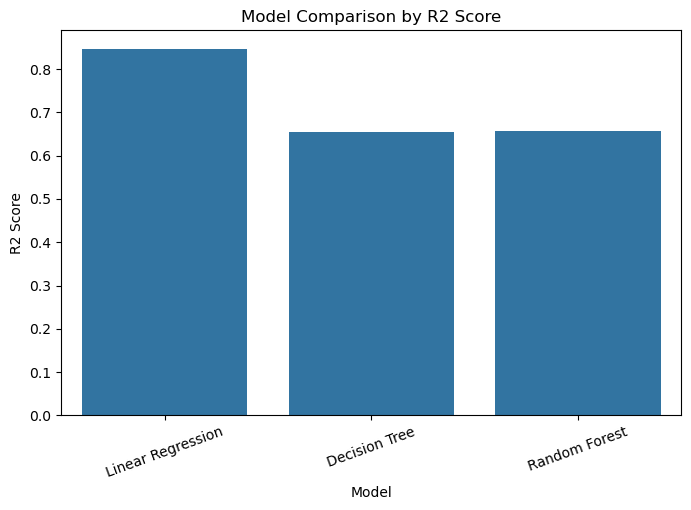

In [43]:
plt.figure(figsize=(8, 5))
sns.barplot(data=model_comparison, x="Model", y="R2 Score")
plt.title("Model Comparison by R2 Score")
plt.xticks(rotation=20)
plt.show()

### Model Comparison

The trained models were compared using MAE, MSE, RMSE, and R² score.

A lower MAE, MSE, and RMSE indicates better prediction accuracy, while a higher R² score indicates that the model explains more variation in house prices.

The best model will be selected based on high R² score and low prediction error.

In [44]:
# Select the best model
best_model = linear_model

print("Best Model Selected: Linear Regression")

Best Model Selected: Linear Regression


In [45]:
# Final predictions using best model
final_predictions = best_model.predict(X_test)

final_results = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": final_predictions
})

final_results.head(10)

,Actual Price,Predicted Price
0,48776607,4.794452e+07
1,36627546,3.610602e+07
2,19628625,1.918321e+07
3,28506065,2.886944e+07
4,38762907,3.850657e+07
5,43138178,4.504536e+07
6,26921839,2.595640e+07
7,36192928,3.761736e+07
8,30025879,3.027543e+07
9,41893150,4.349420e+07


In [46]:
# Create readable actual vs predicted results
final_results = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": final_predictions
})

final_results["Error"] = final_results["Actual Price"] - final_results["Predicted Price"]
final_results["Absolute Error"] = abs(final_results["Error"])

final_results.head(10).style.format({
    "Actual Price": "{:,.0f}",
    "Predicted Price": "{:,.0f}",
    "Error": "{:,.0f}",
    "Absolute Error": "{:,.0f}"
})

,Actual Price,Predicted Price,Error,Absolute Error
0,"48,776,607","47,944,520","832,087","832,087"
1,"36,627,546","36,106,016","521,530","521,530"
2,"19,628,625","19,183,211","445,414","445,414"
3,"28,506,065","28,869,435","-363,370","363,370"
4,"38,762,907","38,506,566","256,341","256,341"
5,"43,138,178","45,045,359","-1,907,181","1,907,181"
6,"26,921,839","25,956,405","965,434","965,434"
7,"36,192,928","37,617,356","-1,424,428","1,424,428"
8,"30,025,879","30,275,433","-249,554","249,554"
9,"41,893,150","43,494,197","-1,601,047","1,601,047"


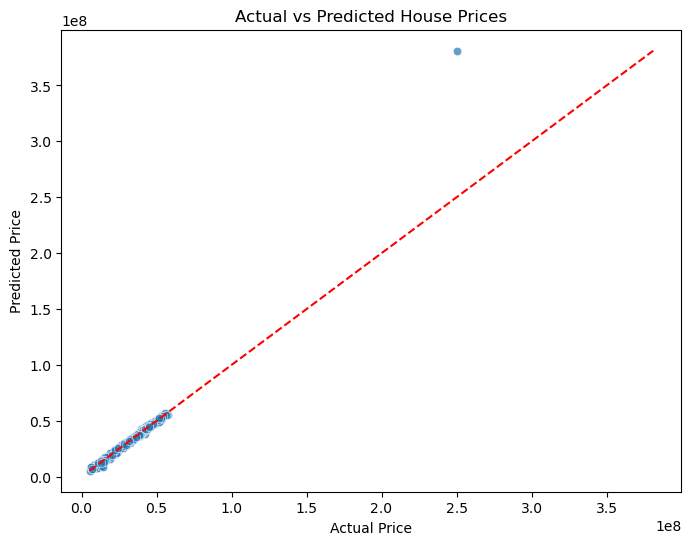

In [47]:
# Actual vs Predicted Price plot with reference line
plt.figure(figsize=(8, 6))

sns.scatterplot(x=y_test, y=final_predictions, alpha=0.7)

min_price = min(y_test.min(), final_predictions.min())
max_price = max(y_test.max(), final_predictions.max())

plt.plot([min_price, max_price], [min_price, max_price], color="red", linestyle="--")

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices")

plt.show()

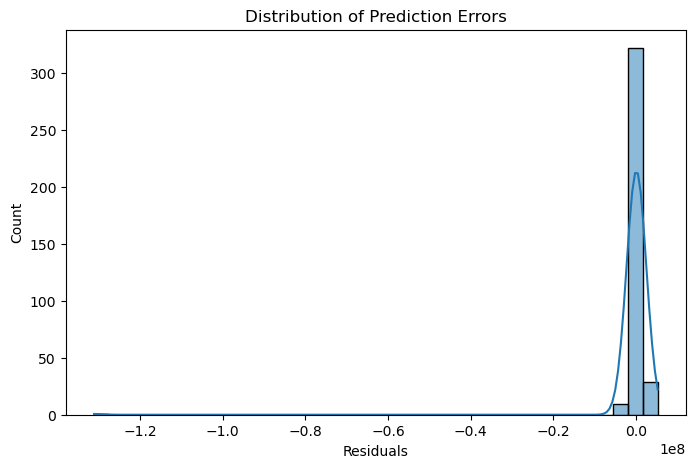

In [48]:
# Calculate residuals
residuals = y_test - final_predictions

# Residual distribution
plt.figure(figsize=(8, 5))

sns.histplot(residuals, kde=True)

plt.xlabel("Residuals")
plt.title("Distribution of Prediction Errors")

plt.show()

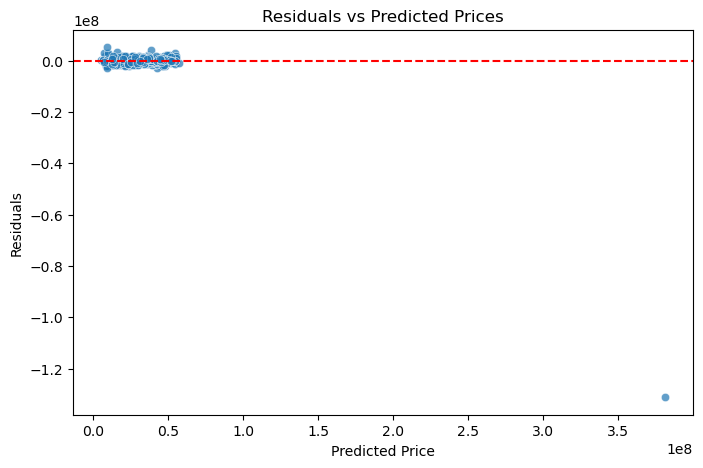

In [49]:
# Residuals vs predicted values
plt.figure(figsize=(8, 5))

sns.scatterplot(x=final_predictions, y=residuals, alpha=0.7)
plt.axhline(y=0, color="red", linestyle="--")

plt.xlabel("Predicted Price")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted Prices")

plt.show()

In [50]:
import joblib
import os

# Create outputs folder if it does not exist
os.makedirs("outputs", exist_ok=True)

# Save final model pipeline
model_path = "outputs/house_price_linear_regression_pipeline.pkl"

joblib.dump(best_model, model_path)

print(f"Model saved successfully at: {model_path}")

Model saved successfully at: outputs/house_price_linear_regression_pipeline.pkl


In [51]:
# Load saved model
loaded_model = joblib.load(model_path)

# Test loaded model on sample test data
loaded_predictions = loaded_model.predict(X_test.head())

loaded_predictions

array([47944519.8920012 , 36106016.36897096, 19183210.77034424,
       28869435.47200239, 38506566.38931479])

In [52]:
# Create a new sample house
new_house = pd.DataFrame({
    "area_sqft": [3500],
    "bedrooms": [4],
    "bathrooms": [3],
    "stories": [2],
    "parking_spaces": [2],
    "house_age": [10],
    "distance_city_km": [12],
    "property_type": ["House"],
    "location_quality": ["High"],
    "furnishing_status": ["Semi-Furnished"],
    "mainroad": ["Yes"],
    "basement": ["No"],
    "has_garden": ["Yes"]
})

# Predict price using saved best model
predicted_price = best_model.predict(new_house)

print(f"Predicted House Price: {predicted_price[0]:,.2f}")

Predicted House Price: 33,786,319.29


In [ ]:
# Create a new sample house
new_house = pd.DataFrame({
    "area_sqft": [3500],
    "bedrooms": [4],
    "bathrooms": [3],
    "stories": [2],
    "parking_spaces": [2],
    "house_age": [10],
    "distance_city_km": [12],
    "property_type": ["House"],
    "location_quality": ["High"],
    "furnishing_status": ["Semi-Furnished"],
    "mainroad": ["Yes"],
    "basement": ["No"],
    "has_garden": ["Yes"]
})

# Predict price using saved best model
predicted_price = best_model.predict(new_house)

print(f"Predicted House Price: {predicted_price[0]:,.2f}")

Predicted House Price: 33,786,319.29


In [53]:
import joblib

joblib.dump(best_model, "outputs/house_price_linear_regression_pipeline.pkl")

['outputs/house_price_linear_regression_pipeline.pkl']